In [24]:
!pip install pandas matplotlib seaborn numpy IPython


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from IPython.display import display, Markdown

# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 6)

# Paths to CSVs
BASELINE_DIR = '../Results/baseline'
ESTIMATED_DIR = '../Results/estimated'
PLOT_DIR = 'plot'
os.makedirs(PLOT_DIR, exist_ok=True)

# Load data
df_base_aicore2 = pd.read_csv(f'{BASELINE_DIR}/performance_baseline_results_devcloudaicore2.2.csv')
df_base_aicore4 = pd.read_csv(f'{BASELINE_DIR}/performance_baseline_results_devcloudaicore4.0.csv')
df_base_cubemx = pd.read_csv(f'{BASELINE_DIR}/performance_baseline_results_cubemx.csv')
df_base_aistudio = pd.read_csv(f'{BASELINE_DIR}/performance_baseline_results_aistudio.csv')

df_est_aistudio = pd.read_csv(f'{ESTIMATED_DIR}/performance_estimated_results_aistudio.csv')

# Pre-processing: convert Inference Time to numeric (coerces 'FAIL' to NaN)
for df in [df_base_aicore2, df_base_aicore4, df_base_cubemx, df_base_aistudio]:
    df['Inference Time (ms)'] = pd.to_numeric(df['Inference Time (ms)'], errors='coerce')


# NPU Performance Analysis
This notebook tells the story of the STM32N6 NPU capabilities, illustrating exactly what it accelerates and where its physical limits lie.
We will explore the raw performance of the most modern tool, **AI STUDIO**, breaking down its optimizations and bottlenecks.
Then, we will compare the compiler evolution (v2.2 vs v4.0) both locally and in the cloud.
Finally, we will analyze the reliability of the compiler estimates versus actual hardware execution.

## 0. Overview of Tested Models and CPU Fallback
Before diving into performance metrics, let's look at the dataset. We tested multiple single-layer sub-models to stress-test specific features of the NPU (various kernel sizes, point-wise, depth-wise, and pooling layers).

In [26]:
overview_df = df_base_aistudio[['Model Name', 'Layer Type', 'Filters', 'Kernel Size', 'MACC', 'CPU Fallback (%)', 'NPU Allocation (%)']].copy()
overview_df['Model Name'] = overview_df['Model Name'].str.replace('baseline_', '').str.replace('_int8', '')
overview_df.sort_values(by='MACC', inplace=True)
overview_df.reset_index(drop=True, inplace=True)

display(overview_df)

cpu_fallback_mean = pd.to_numeric(overview_df['CPU Fallback (%)'], errors='coerce').fillna(0).mean()
display(Markdown(f"**Key Takeaway:** As shown in the table above, the NPU Allocation is consistently 100% and there is **{cpu_fallback_mean:.1f}% CPU Fallback**. This means the STM32N6 NPU natively supports and accelerates all these layer types (Conv2D, Depthwise, MaxPool) entirely in hardware. The Cortex-M CPU never has to intervene to compute unsupported operators."))


,Model Name,Layer Type,Filters,Kernel Size,MACC,CPU Fallback (%),NPU Allocation (%)
0,depthwise_3x3,DepthwiseConv2D,3,3x3,122883,0,100
1,conv2d_1x1,Conv2D (Pointwise),32,1x1,524320,0,100
2,conv2d_16f_3x3,Conv2D,16,3x3,1835024,0,100
3,conv2d_poll,Conv2D + MaxPool,16,3x3,1851408,0,100
4,conv2d_3x3,Conv2D,32,3x3,3670048,0,100
5,conv2d_64f_3x3,Conv2D,64,3x3,7340096,0,100
6,conv2d_32f_5x5,Conv2D,32,5x5,9961504,0,100
7,conv2d_32f_7x7,Conv2D,32,7x7,19398688,0,100


**Key Takeaway:** As shown in the table above, the NPU Allocation is consistently 100% and there is **0.0% CPU Fallback**. This means the STM32N6 NPU natively supports and accelerates all these layer types (Conv2D, Depthwise, MaxPool) entirely in hardware. The Cortex-M CPU never has to intervene to compute unsupported operators.

## Part 1: AI STUDIO - Unveiling the Modern Tool
Let's analyze the performance strictly within the AI STUDIO environment.

### 1.1 What the NPU Accelerates: Operator Fusion
We compare a standard convolution layer with a convolution followed by a Max Pooling layer.

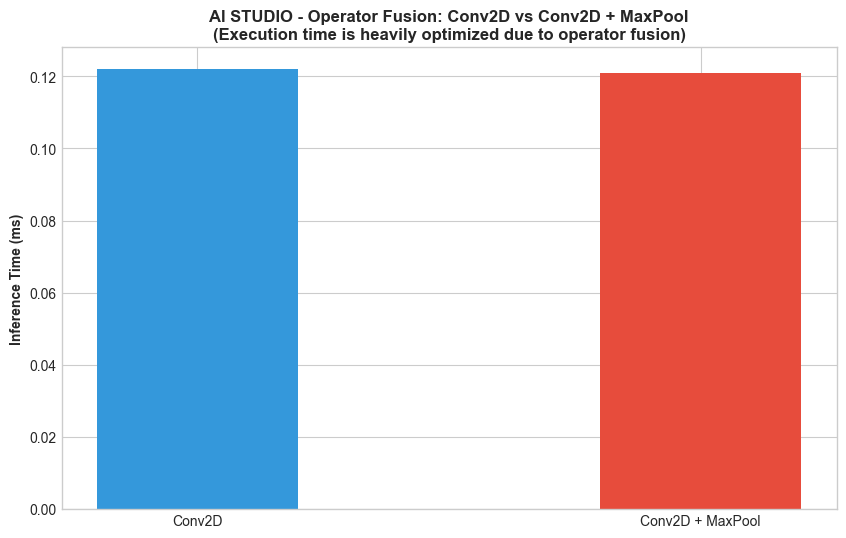

**Why it accelerates:** The NPU is able to fuse the MaxPool operator directly into the pipeline of the Conv2D execution. It does not need to write the Conv2D output to RAM and read it back for Pooling, meaning adding pooling costs almost 0 latency overhead.

In [27]:
# Operator fusion (AI Studio)
models_fusion = ['baseline_conv2d_16f_3x3_int8', 'baseline_conv2d_poll_int8', 'baseline_conv2d_pool_int8']
df_fusion = df_base_aistudio[df_base_aistudio['Model Name'].isin(models_fusion)].copy()
df_fusion['Layer'] = df_fusion['Model Name'].apply(lambda x: 'Conv2D + MaxPool' if 'poll' in x or 'pool' in x else 'Conv2D')

fig, ax1 = plt.subplots()
ax1.bar(df_fusion['Layer'], df_fusion['Inference Time (ms)'], color=['#3498db', '#e74c3c'], width=0.4)
ax1.set_ylabel('Inference Time (ms)', fontweight='bold')
ax1.set_title('AI STUDIO - Operator Fusion: Conv2D vs Conv2D + MaxPool\n(Execution time is heavily optimized due to operator fusion)', fontweight='bold')
plt.savefig(f'{PLOT_DIR}/1_aistudio_fusion.png', bbox_inches='tight')
plt.show()
display(Markdown("**Why it accelerates:** The NPU is able to fuse the MaxPool operator directly into the pipeline of the Conv2D execution. It does not need to write the Conv2D output to RAM and read it back for Pooling, meaning adding pooling costs almost 0 latency overhead."))

### 1.2 What the NPU Accelerates: Convolution Parallelism
Comparing Standard, Pointwise (1x1), and Depthwise convolutions. 
This highlights how the NPU parallelizes different memory access patterns.

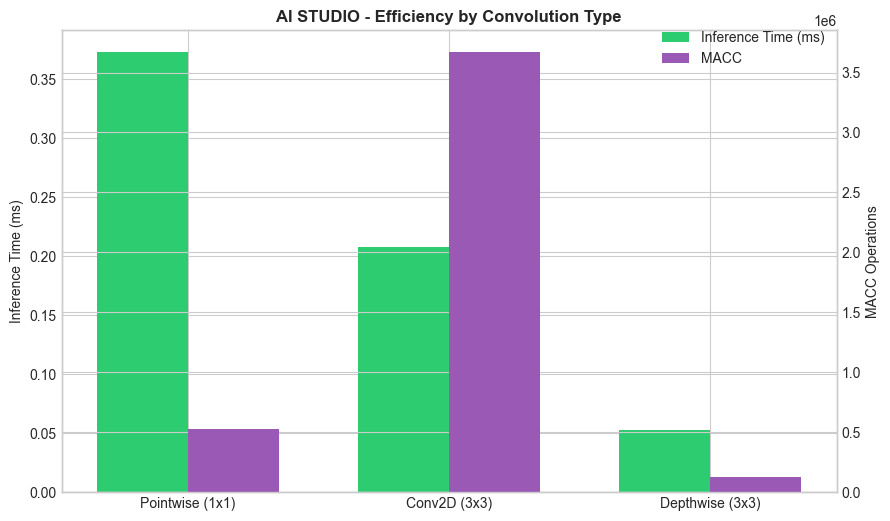

In [28]:
# Kernel efficiency (AI Studio)
models_type = ['baseline_conv2d_3x3_int8', 'baseline_conv2d_1x1_int8', 'baseline_depthwise_3x3_int8']
df_type = df_base_aistudio[df_base_aistudio['Model Name'].isin(models_type)].copy()
name_map = {
    'baseline_conv2d_3x3_int8': 'Conv2D (3x3)',
    'baseline_conv2d_1x1_int8': 'Pointwise (1x1)',
    'baseline_depthwise_3x3_int8': 'Depthwise (3x3)'
}
df_type['Type'] = df_type['Model Name'].map(name_map)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
width = 0.35
x = np.arange(len(df_type['Type']))

ax1.bar(x - width/2, df_type['Inference Time (ms)'], width, label='Inference Time (ms)', color='#2ecc71')
ax2.bar(x + width/2, df_type['MACC'], width, label='MACC', color='#9b59b6')

ax1.set_ylabel('Inference Time (ms)')
ax2.set_ylabel('MACC Operations')
ax1.set_xticks(x)
ax1.set_xticklabels(df_type['Type'])

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('AI STUDIO - Efficiency by Convolution Type', fontweight='bold')
plt.savefig(f'{PLOT_DIR}/2_aistudio_kernel.png', bbox_inches='tight')
plt.show()

### 1.3 Computational Load vs Latency (Compute Bound vs Memory Bound)
A linear trend represents a compute-bound scenario. Deviations indicate memory-bound latency overheads.

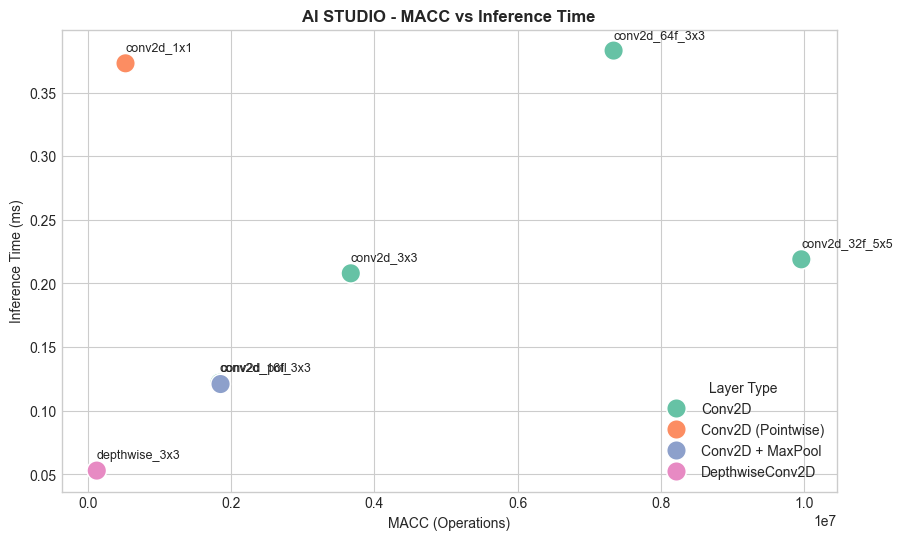

In [29]:
# Compute Bound vs Memory Bound (AI Studio)
df_valid = df_base_aistudio.dropna(subset=['Inference Time (ms)'])

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_valid, x='MACC', y='Inference Time (ms)', hue='Layer Type', s=200, palette='Set2')

for i in range(df_valid.shape[0]):
    plt.text(df_valid['MACC'].iloc[i], df_valid['Inference Time (ms)'].iloc[i] + 0.01, 
             df_valid['Model Name'].iloc[i].replace('baseline_','').replace('_int8',''), 
             fontsize=9)

plt.title('AI STUDIO - MACC vs Inference Time', fontweight='bold')
plt.xlabel('MACC (Operations)')
plt.ylabel('Inference Time (ms)')
plt.savefig(f'{PLOT_DIR}/3_aistudio_macc_vs_latency.png', bbox_inches='tight')
plt.show()

### 1.4 The Limits of the NPU: RAM Saturation
The NPU is not limitless. Here we evaluate what happens when the model size grows (increasing kernel size). 
The 7x7 model exceeds the internal ~1.5MB SRAM limit, forcing the compiler to split the data into multiple 'hardware epochs' and leading to an eventual hardware timeout.

/var/folders/qn/y4fdcgw97jsbxdyb6s0d79680000gn/T/ipykernel_9128/45514970.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_limit.sort_values('RAM Usage (KiB)'), x='Kernel', y='RAM Usage (KiB)', palette='magma')


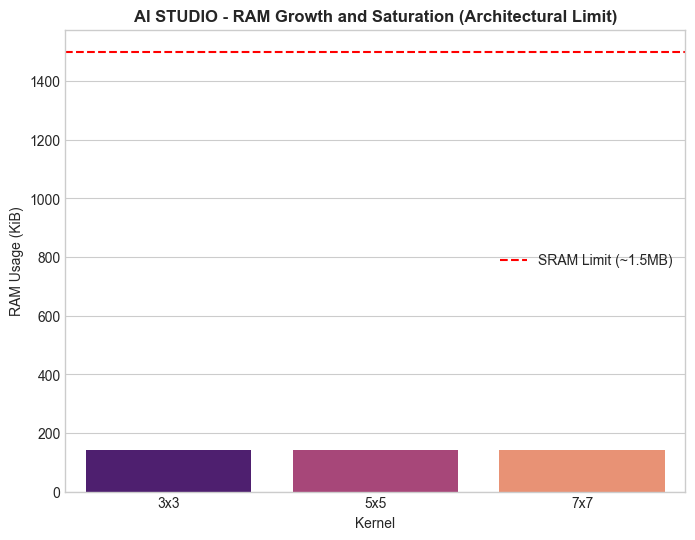

**Where the limit lies:** When we hit the 7x7 filter, RAM saturation spikes above 1.5MB. The internal SRAM is fully utilized, meaning memory has to be chunked into pieces, causing a significant performance drop or execution failure.

In [30]:
# Architectural Limits (AI Studio)
models_limit = ['baseline_conv2d_3x3_int8', 'baseline_conv2d_32f_5x5_int8', 'baseline_conv2d_32f_7x7_int8']
df_limit = df_base_aistudio[df_base_aistudio['Model Name'].isin(models_limit)].copy()
df_limit['Kernel'] = df_limit['Kernel Size']

plt.figure(figsize=(8,6))
sns.barplot(data=df_limit.sort_values('RAM Usage (KiB)'), x='Kernel', y='RAM Usage (KiB)', palette='magma')
plt.axhline(y=1500, color='r', linestyle='--', label='SRAM Limit (~1.5MB)')

plt.title('AI STUDIO - RAM Growth and Saturation (Architectural Limit)', fontweight='bold')
plt.legend()
plt.savefig(f'{PLOT_DIR}/4_aistudio_ram_saturation.png', bbox_inches='tight')
plt.show()
display(Markdown("**Where the limit lies:** When we hit the 7x7 filter, RAM saturation spikes above 1.5MB. The internal SRAM is fully utilized, meaning memory has to be chunked into pieces, causing a significant performance drop or execution failure."))

## Part 2: Compiler Evolution Comparison
We compare the previous generation compilers (v2.2) against the new generation (v4.0).
We separate the analysis into Local Compilers (CubeMX vs AI Studio) and Cloud Compilers (DevCloud AICore).

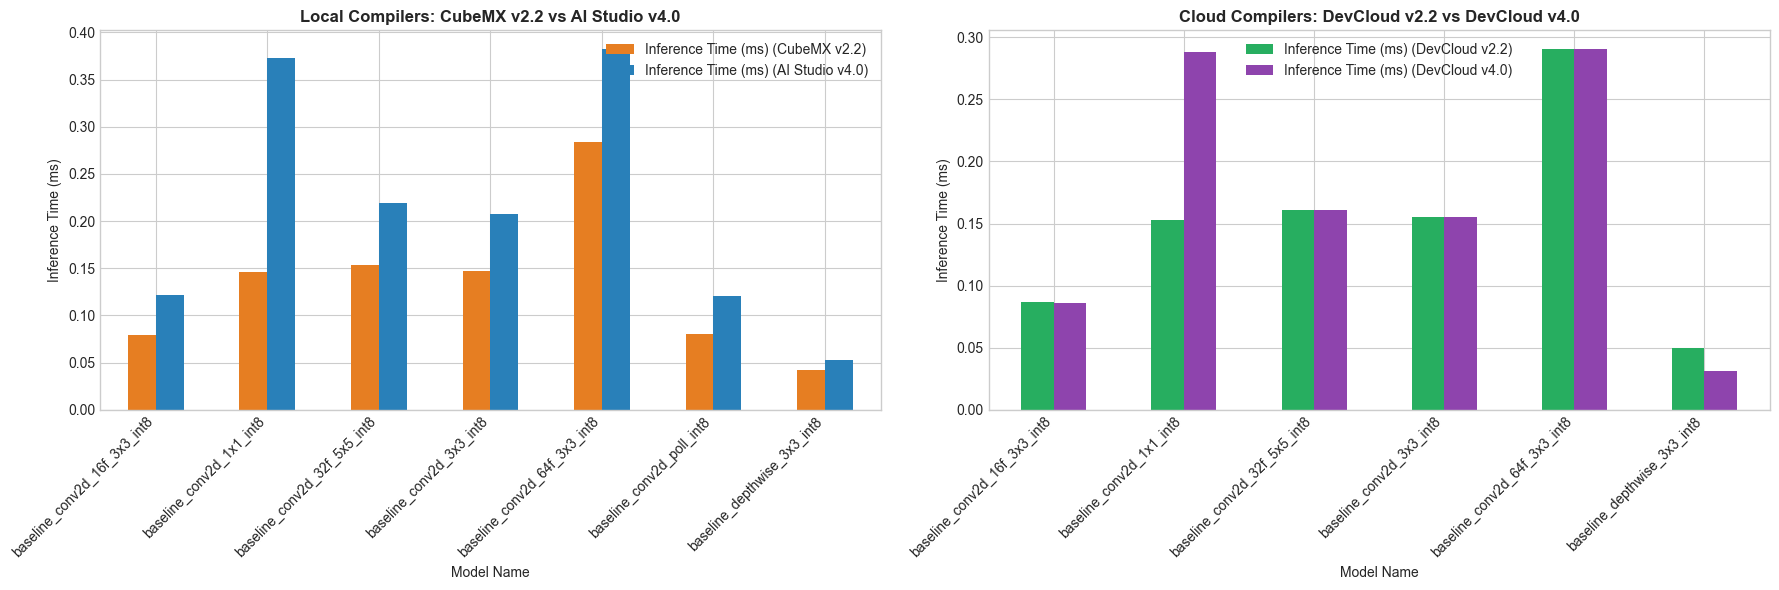

In [31]:
# Compiler Evolution Comparison
df_compare_local = pd.merge(df_base_cubemx[['Model Name', 'Inference Time (ms)']], 
                            df_base_aistudio[['Model Name', 'Inference Time (ms)']], 
                            on='Model Name', suffixes=(' (CubeMX v2.2)', ' (AI Studio v4.0)'))

df_compare_cloud = pd.merge(df_base_aicore2[['Model Name', 'Inference Time (ms)']], 
                            df_base_aicore4[['Model Name', 'Inference Time (ms)']], 
                            on='Model Name', suffixes=(' (DevCloud v2.2)', ' (DevCloud v4.0)'))

df_compare_local = df_compare_local.dropna().set_index('Model Name')
df_compare_cloud = df_compare_cloud.dropna().set_index('Model Name')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_compare_local.plot(kind='bar', ax=axes[0], color=['#e67e22', '#2980b9'])
axes[0].set_title('Local Compilers: CubeMX v2.2 vs AI Studio v4.0', fontweight='bold')
axes[0].set_ylabel('Inference Time (ms)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

df_compare_cloud.plot(kind='bar', ax=axes[1], color=['#27ae60', '#8e44ad'])
axes[1].set_title('Cloud Compilers: DevCloud v2.2 vs DevCloud v4.0', fontweight='bold')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/5_compiler_comparison.png')
plt.show()

## Part 3: Estimated vs Actual Real Data
How reliable are the compiler's memory estimates? 
We compare the AI STUDIO Estimated RAM footprint generated during compilation against the Actual RAM allocated on the board.

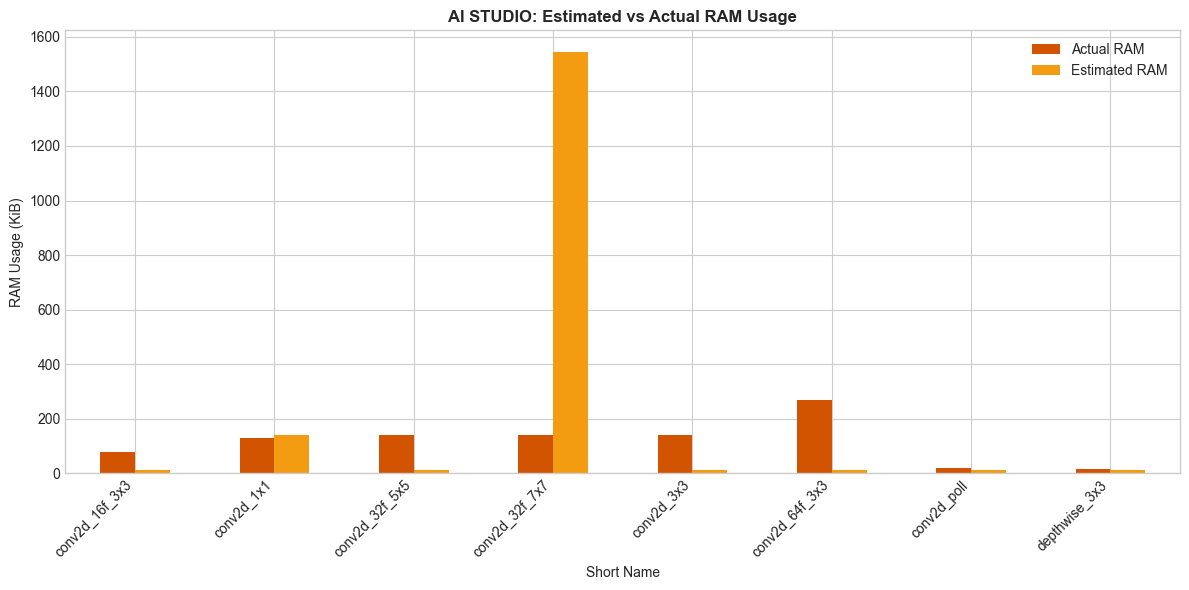

In [32]:
# Estimated vs Real Data (AI STUDIO)
df_est_real = pd.merge(df_base_aistudio[['Model Name', 'RAM Usage (KiB)']], 
                       df_est_aistudio[['Model Name', 'Estimated RAM Usage (KiB)']], 
                       on='Model Name')

# Clean model names for better visualization
df_est_real['Short Name'] = df_est_real['Model Name'].str.replace('baseline_', '').str.replace('_int8', '')
df_est_real.set_index('Short Name', inplace=True)
df_est_real.drop(columns=['Model Name'], inplace=True)
df_est_real.rename(columns={'RAM Usage (KiB)': 'Actual RAM', 'Estimated RAM Usage (KiB)': 'Estimated RAM'}, inplace=True)

df_est_real.plot(kind='bar', figsize=(12, 6), color=['#d35400', '#f39c12'])
plt.title('AI STUDIO: Estimated vs Actual RAM Usage', fontweight='bold')
plt.ylabel('RAM Usage (KiB)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/6_estimated_vs_real_ram.png')
plt.show()